# Replikasi Eksperimen Giudici et al. (2020)
## Network Models to Improve Automated Cryptocurrency Portfolio Management

Notebook ini membandingkan strategi portofolio berikut:
1. **Equally Weighted (EW)** – Portofolio naif 1/N
2. **Classical Markowitz (CM)** – Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** – Markowitz dengan regularisasi Graphical Lasso
4. **Network Markowitz (NW)** – RMT + MST + penalti sentralitas eigenvector
5. **Graph Diversification** – Maximum Independent Set (MIS) dengan threshold statis
6. **Dynamic Graph Diversification (ML Level 1)** – Theta dioptimalkan secara dinamis
7. **Adaptive Graph-Gated Portfolio (AGGP)** – Model hibrida berbasis graph density

---
## Sel 1 – Persiapan Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 – Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada dataset return harian untuk 10 aset kripto utama dalam periode **14 September 2017 – 17 Oktober 2019**.

In [2]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
print(f"Assets: {crypto_names}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00
Assets: ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


---
## Sel 3 – Statistik Ringkasan (Table 1)

Tabel statistik deskriptif mencakup Mean, Standar Deviasi, Kurtosis, dan Skewness untuk setiap aset.

In [3]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 – Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi 100 pada tanggal 7 Januari 2018.

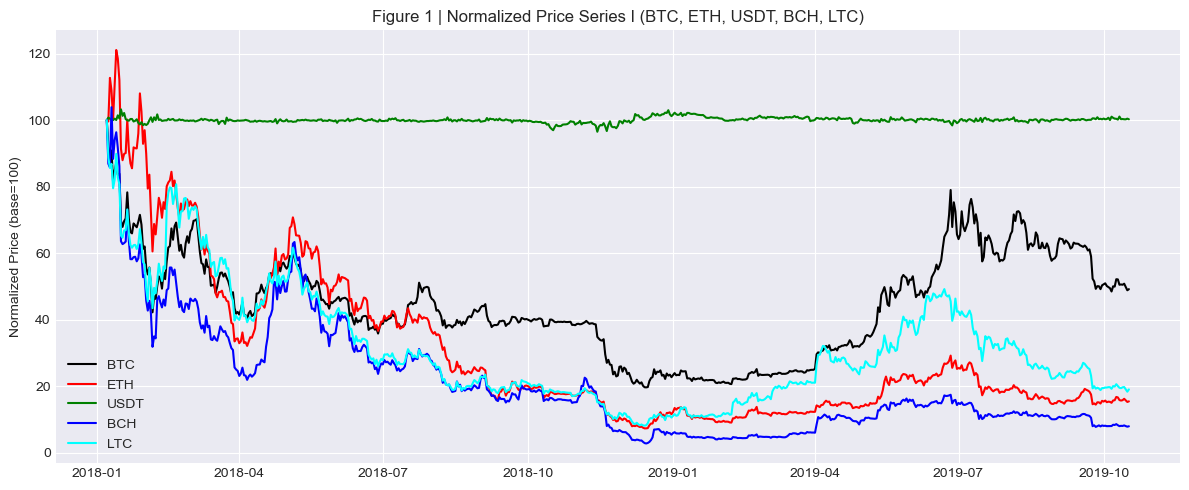

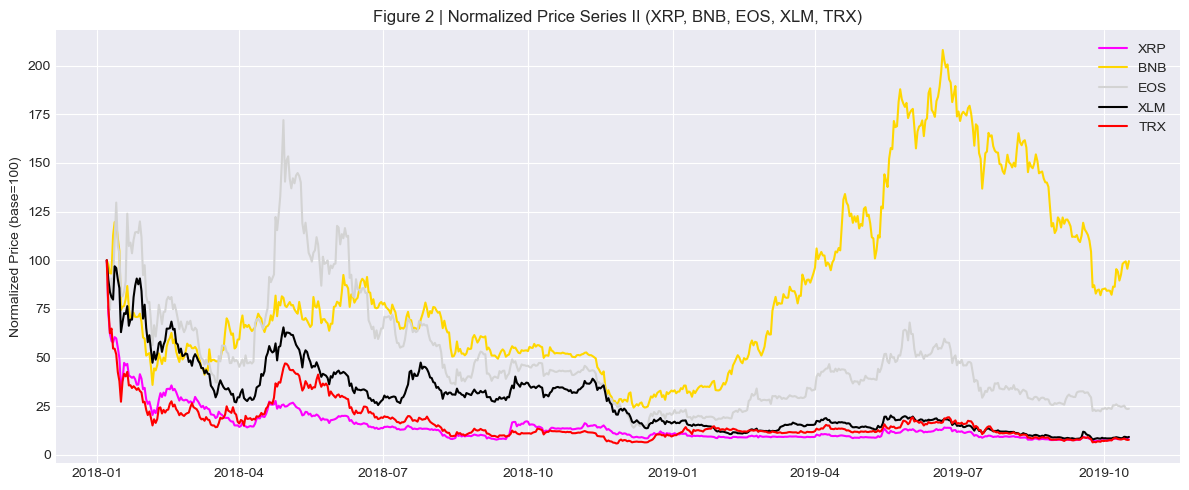

In [4]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 – Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 dari paper acuan: struktur jaringan selama periode gelembung spekulatif (Sep 2017 – Jan 2018).

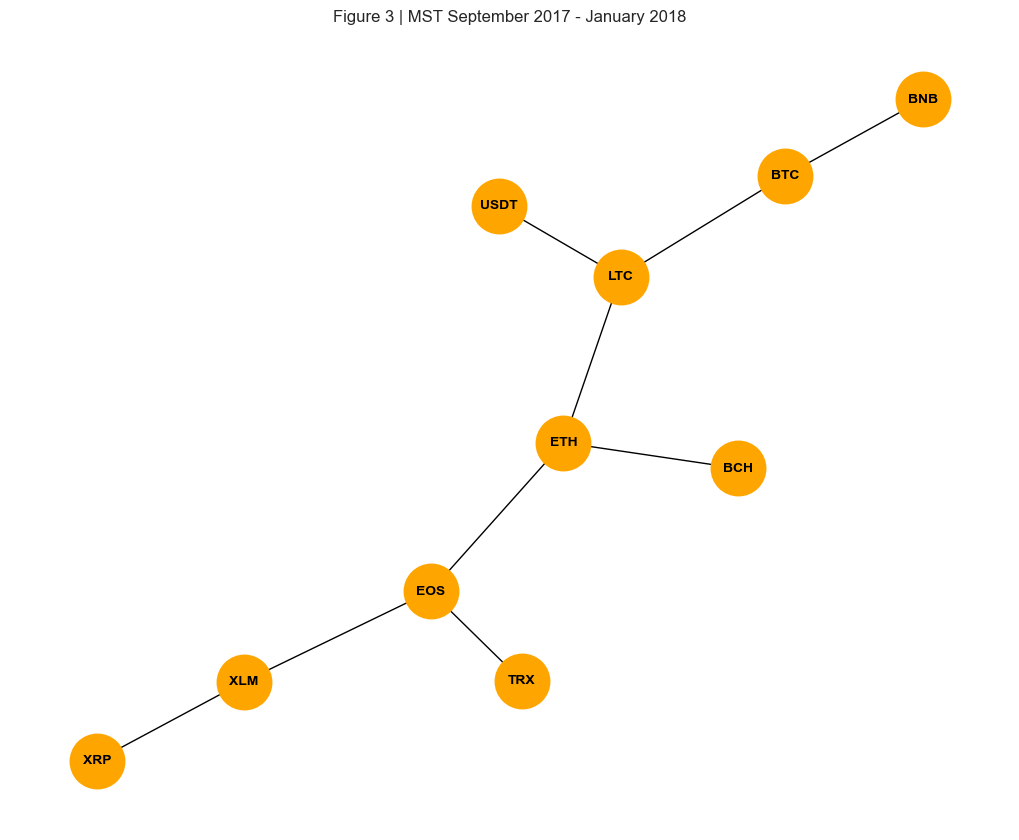

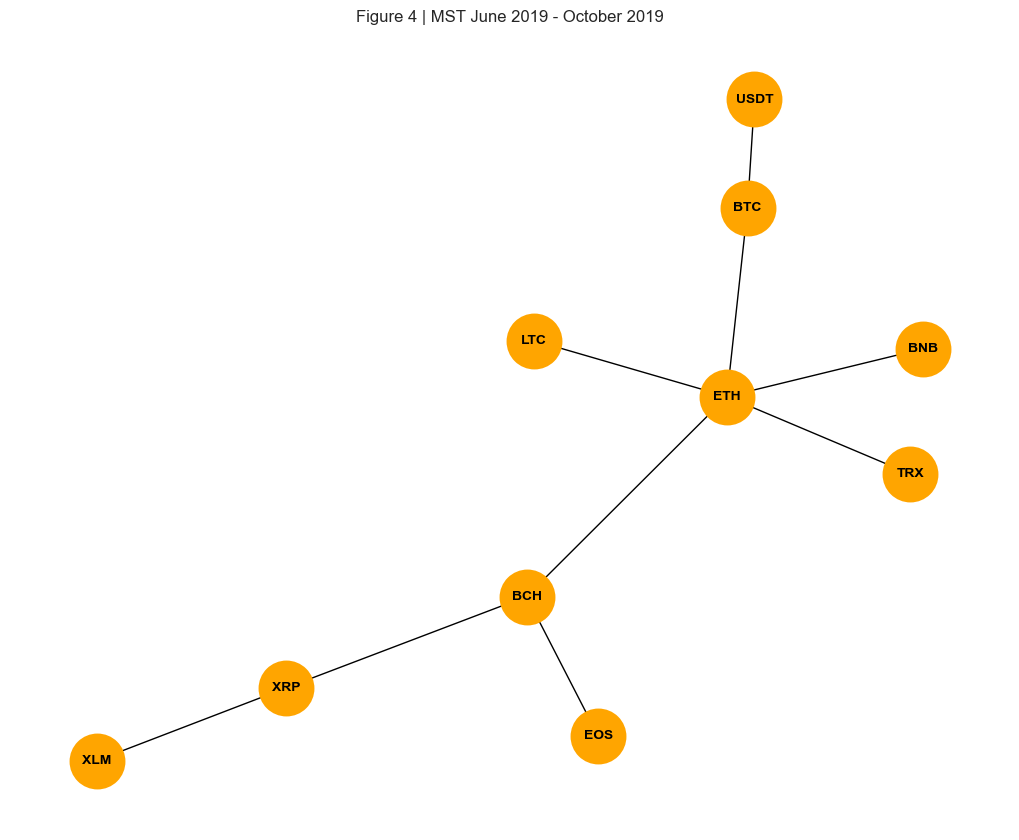

In [5]:
# --- Figure 3 | MST Speculative Bubble Period ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.tight_layout()
plt.show()

# --- Figure 4 | MST Stable Period ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sel 6 – Fungsi Pembantu (Helper Functions)

Implementasi:
- **RMT Filter** – penyaringan noise matriks korelasi via Random Matrix Theory (Marcenko-Pastur)
- **MST Builder** – konstruksi jarak MST dari matriks korelasi
- **Eigenvector Centrality** – sentralitas aset dalam jaringan
- **Risk Metrics** – VaR, Max Drawdown, Rachev Ratio
- **Graph Diversification** – seleksi aset via Maximum Independent Set (MIS)

In [6]:
# ── RMT Filter ──────────────────────────────────────────────────────────────
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory."""
    data = returns_data.values if isinstance(returns_data, pd.DataFrame) else returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)   # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


# ── MST Builder ─────────────────────────────────────────────────────────────
def build_mst(correlation_matrix):
    """Hitung matriks jarak untuk MST dari matriks korelasi."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


# ── Eigenvector Centrality ───────────────────────────────────────────────────
def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality


# ── Risk Metrics ─────────────────────────────────────────────────────────────
def calculate_var(returns, confidence=0.95):
    """Value at Risk pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio = CVaR_upper (alpha) / CVaR_lower (alpha)."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Maximum Drawdown dari seri cumulative return."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


# ── Graph Diversification (MIS) ──────────────────────────────────────────────
def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Cari aset independen menggunakan Maximum Independent Set (MIS)."""
    corr_mat = returns_window.corr()
    assets   = list(returns_window.mean().sort_values(ascending=False).index)
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """Cari aset independen menggunakan korelasi yang sudah difilter RMT."""
    assets = returns_window.columns.tolist()
    corr_f = apply_rmt_filter(returns_window)
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(corr_f[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New – Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung ambang batas MST (*max link distance*) dan koefisien *residuality*.

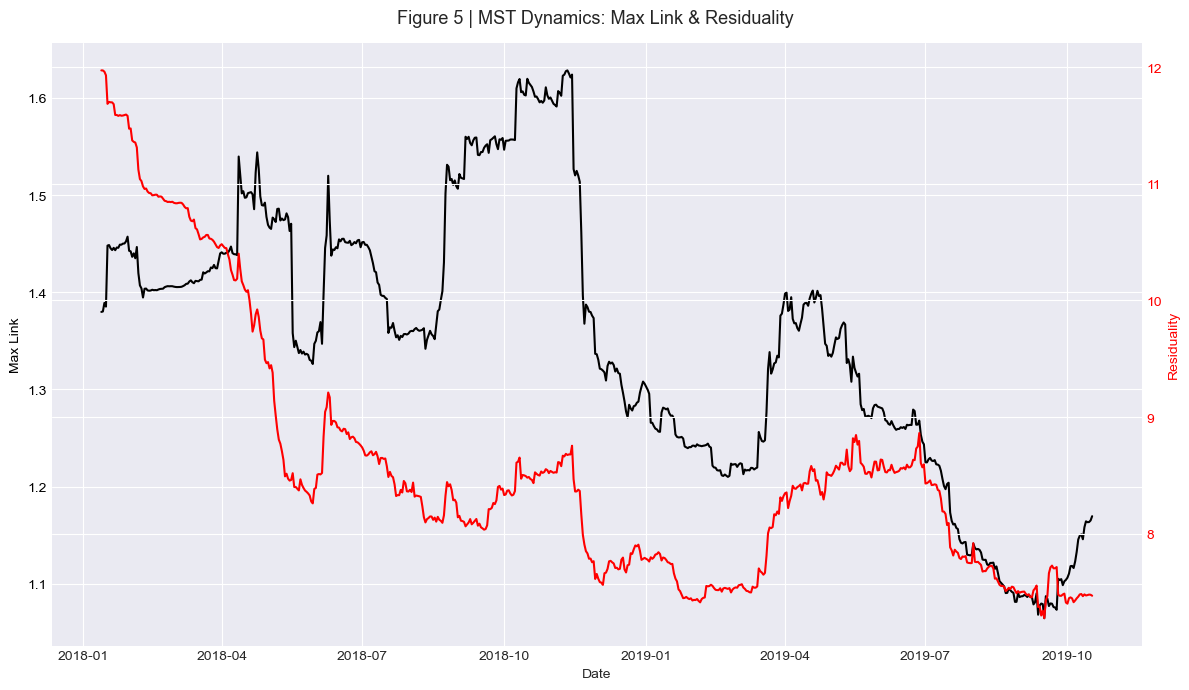

In [7]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


# Hitung dan visualisasikan
mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link', color='black')
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Residuality', color='red')
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Figure 5 | MST Dynamics: Max Link & Residuality', fontsize=13)
fig.tight_layout()
plt.show()

---
## Sel 7 – Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas yang mewarisi `PortfolioStrategy`.

In [8]:
# ── Base Class ───────────────────────────────────────────────────────────────
class PortfolioStrategy:
    def __init__(self, name):
        self.name             = name
        self.weights_history  = []
        self.returns_history  = []

    def get_weights(self, returns_data):
        raise NotImplementedError


# ── Equally Weighted ─────────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# ── Classical Markowitz ──────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        S  = returns_data.cov().values

        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(lambda w: w @ S @ w, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── Glasso Markowitz ─────────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values

        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(lambda w: w @ S @ w, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── Network Markowitz ────────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values
        Cf  = apply_rmt_filter(returns_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf

        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w),
                       np.ones(n) / n, method='SLSQP',
                       bounds=[(0, 1)] * n, constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── Graph Diversification (Static Theta) ────────────────────────────────────
class GraphDiversification(PortfolioStrategy):
    """Strategi diversifikasi berbasis graf menggunakan Maximum Independent Set."""
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── RMT Graph Diversification ────────────────────────────────────────────────
class RMTGraphDiversification(PortfolioStrategy):
    """Graph Diversification dengan korelasi yang difilter RMT."""
    def __init__(self, name='RMT Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify_rmt(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── Dynamic Graph Diversification (ML Level 1) ───────────────────────────────
class DynamicGraphDiversification(PortfolioStrategy):
    """
    Diversifikasi graf dengan optimasi theta secara dinamis (ML Level 1).
    Mencari nilai theta yang meminimalkan volatilitas via rolling cross-validation.
    """
    def __init__(self, name='Dynamic Graph Divers. (ML)'):
        super().__init__(name)

    def optimize_theta(self, returns_data):
        best_theta    = 0.4
        min_vol       = float('inf')
        for theta in np.arange(0.1, 0.9, 0.1):
            sel = get_assets_graph_diversify(returns_data, corr_threshold=round(theta, 2))
            if not sel:
                continue
            assets = returns_data.columns.tolist()
            idx    = [assets.index(a) for a in sel]
            sub    = returns_data.iloc[:, idx]
            port_r = sub.mean(axis=1)
            vol    = port_r.std()
            if vol < min_vol:
                min_vol    = vol
                best_theta = theta
        return best_theta

    def get_weights(self, r):
        n             = r.shape[1]
        assets        = r.columns.tolist()
        optimal_theta = self.optimize_theta(r)
        sel           = get_assets_graph_diversify(r, optimal_theta)
        w             = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── Adaptive Graph-Gated Portfolio (AGGP) ────────────────────────────────────
class AdaptiveGraphPortfolio(PortfolioStrategy):
    """AGGP: Graph Density sebagai pemicu gamma adaptif (Glasso + Network Markowitz)."""
    def __init__(self, name='AGGP (Optimized)', sensitivity=2.0):
        super().__init__(name)
        self.sensitivity = sensitivity

    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV(cv=5)
            glasso.fit(returns_data.values)
            Sf = glasso.covariance_
            Cf = glasso.get_precision()  # precision matrix
            Cf = apply_rmt_filter(returns_data)  # fallback to RMT for correlation
        except Exception:
            Cf = apply_rmt_filter(returns_data)
            Sf = np.outer(returns_data.std(), returns_data.std()) * Cf

        adj     = (np.abs(Cf) > 0.5).astype(int)
        G_tmp   = nx.from_numpy_array(adj)
        density = nx.density(G_tmp)
        gamma_t = np.clip(density * self.sensitivity, 0.1, 0.9)

        dist   = build_mst(Cf)
        cent   = compute_eigenvector_centrality(dist)
        w_net  = 1.0 / (cent + 1e-6)
        w_net /= w_net.sum()

        res_mko = minimize(lambda w: w @ Sf @ w, np.ones(n) / n,
                           method='SLSQP', bounds=[(0, 1)] * n,
                           constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        w_mko = res_mko.x if res_mko.success else np.ones(n) / n
        return (1 - gamma_t) * w_mko + gamma_t * w_net


print("All portfolio strategy classes defined!")

All portfolio strategy classes defined!


---
## Sel 8 – Framework Backtesting

Sistem pengujian menggunakan *rolling window* dengan biaya transaksi 0.1% (10 bps).

In [9]:
def backtest_strategy(strategy, df_returns, window_size=120,
                      rebalance_freq=7, transaction_cost=0.001):
    """
    Simulasi backtest dengan rolling window.

    Parameters
    ----------
    strategy         : PortfolioStrategy instance
    df_returns       : DataFrame return harian
    window_size      : Ukuran jendela training (hari)
    rebalance_freq   : Frekuensi rebalancing (hari)
    transaction_cost : Biaya transaksi per rebalancing (default 0.1%)

    Returns
    -------
    dict berisi: strategy name, returns array, cumulative_returns array, results_df
    """
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train    = df_returns.iloc[i - window_size:i]
        w        = strategy.get_weights(train)
        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':          strategy.name,
        'returns':           np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':        res_df
    }


print("Backtest function defined!")

Backtest function defined!


---
## Sel 9 – Eksekusi Backtesting

Menjalankan semua strategi dengan berbagai nilai parameter $\gamma$.

In [10]:
# --- Inisialisasi strategi ---
gamma_values = [0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
] + [
    NetworkMarkowitz(f"NW (gamma={g})", gamma=g) for g in gamma_values
] + [
    GraphDiversification('Graph Divers. (theta=0.4)', corr_threshold=0.4),
    GraphDiversification('Graph Divers. (theta=0.5)', corr_threshold=0.5),
    RMTGraphDiversification('RMT GD (theta=0.4)',     corr_threshold=0.4),
    DynamicGraphDiversification('Dynamic Graph Divers. (ML)'),
    AdaptiveGraphPortfolio("AGGP (Optimized)", sensitivity=2.0)
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running backtest: {strat.name} ...", end=' ')
    results[strat.name] = backtest_strategy(strat, df_returns)
    print("Done")

print("\nAll backtests completed!")

Running backtest: EW ... Done
Running backtest: CM ... Done
Running backtest: GM ... Done
Running backtest: NW (gamma=0) ... Done
Running backtest: NW (gamma=0.005) ... Done
Running backtest: NW (gamma=0.025) ... Done
Running backtest: NW (gamma=0.05) ... Done
Running backtest: NW (gamma=0.15) ... Done
Running backtest: NW (gamma=0.7) ... Done
Running backtest: NW (gamma=1.0) ... Done
Running backtest: Graph Divers. (theta=0.4) ... Done
Running backtest: Graph Divers. (theta=0.5) ... Done
Running backtest: RMT GD (theta=0.4) ... Done
Running backtest: Dynamic Graph Divers. (ML) ... Done
Running backtest: AGGP (Optimized) ... Done

All backtests completed!


---
## Sel 10 – Analisis Performa Periodik (Table 2)

Perbandingan *cumulative P&L* yang disampel setiap 4 bulan (Januari, Mei, September).

In [11]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')

print("TABLE 2 | Cumulative Profits and Losses (%)")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%)
                            2018-01-31  2018-05-31  2018-09-30  2019-01-31  2019-05-31  2019-09-30
Strategy                                                                                          
EW                              -35.53      -58.96      -77.02      -89.67      -77.88      -88.82
CM                              -34.32      -57.88      -59.66      -68.22      -55.67      -62.16
GM                              -33.86      -60.11      -61.90      -73.12      -62.49      -67.53
NW (gamma=0)                    -41.59      -62.30      -63.81      -71.79      -61.83      -68.05
NW (gamma=0.005)                -41.62      -61.76      -64.22      -71.33      -62.41      -68.75
NW (gamma=0.025)                -44.13      -64.87      -66.29      -66.72      -57.08      -66.33
NW (gamma=0.05)                 -44.80      -63.44      -64.60      -65.06      -55.14      -61.98
NW (gamma=0.15)                 -44.65      -56.79      -58.18   

---
## Sel 11 – Visualisasi Performa Kumulatif (Figure 6)

Pertumbuhan nilai portofolio dengan asumsi investasi awal **100 USD**.

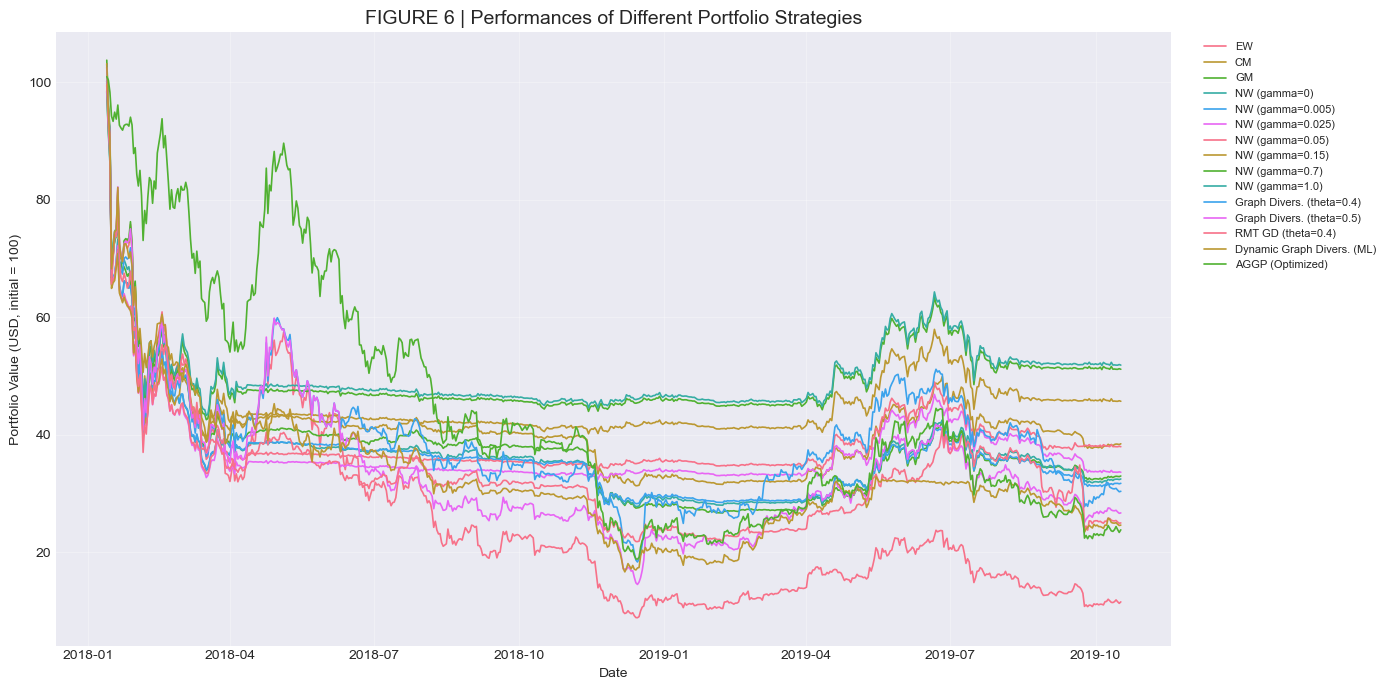

In [12]:
plt.figure(figsize=(14, 7))

for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name, linewidth=1.2)

plt.title('FIGURE 6 | Performances of Different Portfolio Strategies', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD, initial = 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 12 – Analisis Risiko Periodik: VaR (Table 3)

*Value at Risk* 95% dihitung per jendela 4 bulan. Nilai disajikan dalam bentuk absolut × 100.

In [13]:
# Pasangan tanggal awal-akhir untuk jendela 4 bulan
period_windows = [
    ('2017-10-01', '2018-01-31'),
    ('2018-02-01', '2018-05-31'),
    ('2018-06-01', '2018-09-30'),
    ('2018-10-01', '2019-01-31'),
    ('2019-02-01', '2019-05-31'),
    ('2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for start, end in period_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            var_val = abs(calculate_var(segment, 0.95)) * 100
        else:
            var_val = np.nan
        row[end] = round(var_val, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')

print("TABLE 3 | VaR 95% (× 100, absolute value)")
print(table3.to_string())

TABLE 3 | VaR 95% (× 100, absolute value)
                            2018-01-31  2018-05-31  2018-09-30  2019-01-31  2019-05-31  2019-09-30
Strategy                                                                                          
EW                             13.7904      9.5511      6.5477      9.4876      3.6840      8.2085
CM                             12.8261      5.8008      0.9993      1.7255      1.7011      3.8309
GM                             13.4648      5.9287      1.1856      2.4277      1.8379      4.2622
NW (gamma=0)                   12.4709      5.6166      1.1500      1.8397      1.5141      4.0012
NW (gamma=0.005)               12.4241      5.6147      0.8306      1.6875      1.4901      3.4683
NW (gamma=0.025)               12.4356      5.9057      0.7120      0.9561      1.2534      3.1919
NW (gamma=0.05)                12.1764      5.6022      0.7120      0.9561      1.2534      3.0559
NW (gamma=0.15)                11.6335      5.6183      0.7120     

---
## Sel 13 – Analisis Risk-Adjusted Return: Sharpe Ratio (Table 4)

In [14]:
table4_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for start, end in period_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[end] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')

print("TABLE 4 | Sharpe Ratio (4-month windows)")
print(table4.to_string())

TABLE 4 | Sharpe Ratio (4-month windows)
                            2018-01-31  2018-05-31  2018-09-30  2019-01-31  2019-05-31  2019-09-30
Strategy                                                                                          
EW                             -0.2532     -0.0425     -0.0986     -0.1270      0.2016     -0.1298
CM                             -0.2508     -0.0984     -0.0577     -0.1500      0.1904     -0.0598
GM                             -0.2355     -0.1032     -0.0537     -0.1873      0.1775     -0.0526
NW (gamma=0)                   -0.3442     -0.1053     -0.0523     -0.1514      0.1851     -0.0694
NW (gamma=0.005)               -0.3452     -0.1012     -0.1186     -0.1474      0.1691     -0.0730
NW (gamma=0.025)               -0.3860     -0.1095     -0.0710     -0.0152      0.1575     -0.1023
NW (gamma=0.05)                -0.4039     -0.0948     -0.0563     -0.0152      0.1560     -0.0672
NW (gamma=0.15)                -0.4061     -0.0473     -0.0562     -

---
## Sel 14 – Analisis Tail-Risk: Rachev Ratio (Table 5)

Rachev Ratio = CVaR_upper (10%) / CVaR_lower (10%)

In [15]:
table5_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for start, end in period_windows:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 10:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[end] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')

print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month windows)")
print(table5.to_string())

TABLE 5 | Rachev Ratio (alpha=10%, 4-month windows)
                            2018-01-31  2018-05-31  2018-09-30  2019-01-31  2019-05-31  2019-09-30
Strategy                                                                                          
EW                              0.3926      0.8889      0.8062      0.7200      1.7430      0.5381
CM                              0.3969      0.7612      0.7865      0.6506      2.0115      0.7510
GM                              0.4126      0.7515      0.7760      0.5600      1.6893      0.7353
NW (gamma=0)                    0.2494      0.7591      0.7824      0.6389      2.1048      0.7820
NW (gamma=0.005)                0.2478      0.7625      0.6953      0.6421      2.0409      0.7798
NW (gamma=0.025)                0.2332      0.7939      0.7954      1.0171      2.2107      0.7588
NW (gamma=0.05)                 0.1836      0.8387      0.8551      1.0171      2.1777      0.8317
NW (gamma=0.15)                 0.1822      1.0085      0

---
## Sel 15 – Analisis Fase Pasar (Table 6)

Performa setiap strategi dibandingkan pada tiga fase pasar:
- **Bearish**: Januari 2018 – Maret 2019
- **Recovery**: April 2019 – Juni 2019  
- **Stable/Sideways**: Juli 2019 – Oktober 2019

In [16]:
fase_pasar = {
    'Bearish':   ('2018-01-01', '2019-03-31'),
    'Recovery':  ('2019-04-01', '2019-06-30'),
    'Stable':    ('2019-07-01', '2019-10-17')
}

# --- Panel A: Sharpe Ratio ---
panel_a_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        sr = np.mean(segment) / np.std(segment) if len(segment) > 1 else np.nan
        row[fase] = round(sr, 4)
    panel_a_rows.append(row)

panel_a = pd.DataFrame(panel_a_rows).set_index('Strategy')

# --- Panel B: Rachev Ratio ---
panel_b_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        rr = calculate_rachev_ratio(segment, alpha=0.10) if len(segment) > 10 else np.nan
        row[fase] = round(rr, 4)
    panel_b_rows.append(row)

panel_b = pd.DataFrame(panel_b_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
print(panel_a.to_string())
print("\nPanel B: Rachev Ratio (alpha=10%)")
print(panel_b.to_string())

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio
                            Bearish  Recovery  Stable
Strategy                                             
EW                          -0.0726    0.1286 -0.1301
CM                          -0.0923    0.1844 -0.1022
GM                          -0.0991    0.1732 -0.0950
NW (gamma=0)                -0.1072    0.1763 -0.1095
NW (gamma=0.005)            -0.1079    0.1587 -0.1091
NW (gamma=0.025)            -0.0965    0.1376 -0.1326
NW (gamma=0.05)             -0.0921    0.1356 -0.0859
NW (gamma=0.15)             -0.0736    0.1359 -0.0743
NW (gamma=0.7)              -0.0694    0.1359 -0.0628
NW (gamma=1.0)              -0.0685    0.1359 -0.0628
Graph Divers. (theta=0.4)   -0.0389    0.1184 -0.1308
Graph Divers. (theta=0.5)   -0.0499    0.1280 -0.1301
RMT GD (theta=0.4)          -0.0941    0.2175 -0.0858
Dynamic Graph Divers. (ML)  -0.0772    0.1017 -0.1192
AGGP (Optimized)            -0.0651    0.1299 -0.1311

Panel B: Rachev Ratio (

---
## Ringkasan Hasil

Sel ini menyajikan ringkasan metrik performa keseluruhan untuk setiap strategi.

In [17]:
summary_rows = []
for strat_name, res in results.items():
    r   = res['returns']
    cum = res['cumulative_returns']
    summary_rows.append({
        'Strategy':        strat_name,
        'Total Return (%)': round((cum[-1] - 1) * 100, 2),
        'Ann. Vol (%)':    round(r.std() * np.sqrt(252) * 100, 2),
        'Sharpe Ratio':    round(r.mean() / r.std() * np.sqrt(252), 4) if r.std() > 0 else np.nan,
        'Max Drawdown (%)': round(calculate_max_drawdown(cum) * 100, 2),
        'Rachev Ratio':    round(calculate_rachev_ratio(r), 4),
        'VaR 95% (×100)':  round(abs(calculate_var(r, 0.95)) * 100, 4)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Strategy')

print("SUMMARY | Overall Performance Metrics")
print(summary_df.to_string())

SUMMARY | Overall Performance Metrics
                            Total Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)  Rachev Ratio  VaR 95% (×100)
Strategy                                                                                                                
EW                                    -88.49         69.31       -0.8646            -91.45        0.8014          7.7519
CM                                    -61.56         36.13       -0.8464            -69.50        0.7734          3.6092
GM                                    -67.05         38.36       -0.9317            -74.31        0.7402          4.2237
NW (gamma=0)                          -67.56         35.00       -1.0727            -72.30        0.7487          3.1887
NW (gamma=0.005)                      -68.30         34.60       -1.1153            -71.82        0.7478          3.1950
NW (gamma=0.025)                      -66.40         33.95       -1.0766            -67.66        0.7596          2